# Biomolecular simulation with GROMACS

In this tutorial, we will go over the very basics of standard biomolecular simulation. For that, we will use [GROMACS](https://www.gromacs.org/), one of the most widely used MD engines when it comes to biomolecules. GROMACS is a highly optimised package, with literal decades of development and the first choice for thousands of researches around the world. This tutorial will NOT be an exhaustive look into everything one can do with GROMACS, since the ecosystem is huge and can take years to master completely. Instead, we will familiarise ourselves with its basic command line interface and, hopefully, in the end we will be able to comfortably set up simple systems and run unrestrained MD simulations.

## Part 1 - Preparing a protein simulation

In the first part of the tutorial we will learn how to prepare a small protein-in-water system and get it ready for a production simulation. We will start from a PDB file containing only the protein and end up with some GROMACS binaries ready to run.

### 1.1 - Familiarising ourselves with the system

The very first thing we should really do is visualize the system that we want to simulate. 

The following display is interactive, play with it for a while. What kind of molecule are we dealing with? What can you tell me about it? Why does it "move" if it is only one PDB file?

In [1]:
import MDAnalysis as mda
import nglview as nv

u_2RVD = mda.Universe("structures/2RVD.pdb")
nv.show_mdanalysis(u_2RVD)

/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


NGLWidget(max_frame=19)

It is probably a good idea we inspect the [PDB file](structures/2RVD.pdb). Open it in another tab. You will see ato some point these two lines:

```text
KEYWDS    BETA-HAIRPIN, MINI-PROTEIN, CHIGNOLIN, DE NOVO PROTEIN                
EXPDTA    SOLUTION NMR
```

Here we actually have some answers to the previous questions! We are dealing with a *de novo* designed protein, a beta-hairpin, studied through solution NMR. A bit further down we will read:

```text
REMARK 210 BEST REPRESENTATIVE CONFORMER IN THIS ENSEMBLE : 1
```

So this is a conformational ensemble! That explains why the molecule "moves" in the visualiser, every frame corresponds to one conformation. We are also told that the most representative conformer is the first one. Probably, then, it is a good idea if we save it.

In [2]:
u_2RVD.trajectory[0] # Conformers are stored as if they were a trajectory
u_2RVD.atoms.write("exercise-1/2RVD_conf1.pdb")

u_conf1 = mda.Universe("exercise-1/2RVD_conf1.pdb")
nv.show_mdanalysis(u_conf1)


/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


NGLWidget()

Now we can see that there is no play button on the visualizer, and have just one structure. This will be our starting point and we are now ready to really start thinking about setting up the simulation.

### 1.2 - Preparation of the structure

Let's think now about where does this protein live. Is it in vaccuum? Does it occupy any space at all? Surely, it must, right? Luckily PDB files provide us with that kind of information. If we keep reading the PDB file we will bump into these lines:

```text
REMARK 215 THE COORDINATES IN THIS ENTRY WERE GENERATED FROM SOLUTION           
REMARK 215 NMR DATA.  PROTEIN DATA BANK CONVENTIONS REQUIRE THAT                
REMARK 215 CRYST1 AND SCALE RECORDS BE INCLUDED, BUT THE VALUES ON              
REMARK 215 THESE RECORDS ARE MEANINGLESS.  
```

What this means, really, is that there is really no unit-cell information for this system, this is, for all effects the protein is sitting in vacuum in an infinitely large box. That is not desirable for a condensed matter system. We would like our protein to be contained in a finite volume and be solvated by something.

Let's start with putting our protein in a finite box. This will be the first GROMACS command we will run. Open a terminal, and type the following

```bash
gmx editconf -f exercise-1/2RVD_conf1.pdb -o exercise-1/2RVD_box.pdb -box 5 5 5
```

`editconf` means edit conformation, and is a command that allows simple manipulations of structure files, like translations, rotations and, in this case, adding a simulation box. We use `-f` to indicate the input file, `-o` for an output file and `-box` to give the size of the box in nanometres. By default, the box is an ortorrhombic box, so the angles between the box vectors will be 90 degrees. `editconf` can take many more options, you can inspect all you can do with it if you run `gmx editconf -h`; and this is true for all available GROMACS commands.

We can now visualise the result of the previous operation.

In [3]:
u_box = mda.Universe("exercise-1/2RVD_box.pdb")

view = nv.show_mdanalysis(u_box)
view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="protein")
view.add_unitcell()
view.center()
view

NGLWidget()

We now see a box around our protein! Now GROMACS will understand that the protein must live at all times in that volume and does not have (in principle) an infinite space to go around. We will see in a bit why I said *in principle*. 

However, our protein still looks quite lonely in the middle of that box. In nature, proteins usually do not appear in vacuum, unless something goes really, *really* wrong. We must therefore fix this and **solvate** the protein. The solvent of choice will be, of course, water; since that is the solvent of life. We can use GROMACS for that, in the same terminal you opened before, run:

```bash
gmx solvate -cp exercise-1/2RVD_box.pdb -o exercise-1/2RVD_solv.pdb
```

In this case `solvate` is pretty much self-explanatory. `-cp` stands for Conformation of the Protein and is used to pass the conformation of the thing to be solvated. Despite its name, you do NOT need to pass necessarily a protein, it can really be anything. Again, with `-o` we decide the output file.

We can visualise the result of this:

In [12]:
u_solv = mda.Universe("exercise-1/2RVD_solv.pdb")

view = nv.show_mdanalysis(u_solv)
view.clear_representations()
view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="SOL")
view.add_unitcell()
view

/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:372: UserWarning: Unknown element  found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)


NGLWidget()

Now, that looks much better! We have quite a few waters accompanying our protein now. However, you may notice something that could seem strange at first: why are some water molecules **outside** the simulation box?

The answer to that question is that they actually aren't! In condensed-matter simulation we will work, more often than not, under Periodic Boundary Conditions (PBC). Think about pac-man, he comes out one side of the map and immediately appears again through the wall in the opposite side. This is exactly what is happening here, the water molecules that appear outside the box are actually inside, just on the opposite side. This is, partly, why I mentioned before that the atoms have *in principle* a finite volume to move. The **are** constrained within a simulation box, but that doesn't mean they will bounce off its limits, they can actually diffuse freely as much as they want. Moreover, the simulation boxed do not necessarily stay the same, but can (and usually should!) change as the simulation progresses. Again, more on this later.

With this, we have now a much more decent system and we can move to the next part of the tutorial.

### 1.3 - Parameter assignement

So far, we have just sort of manually placed molecules and atoms in a simulation box, but we have not run any simulation yet; no energies, no forces, no dynamics, no movement whatsoever. We must raise the question, however, of how will we inform our simulation engine about how to actually simulate our system. First and foremost, thus, we must decide our force field. 

*Force field* is just a fancy term to call the set equations that will be used to describe our system. Think, for example, how can we describe a bond between two particles, maybe with a harmonic potential? What about electrostatic interactions, surely we would use the Coulomb potential? And dispersion-repulsion forces, maybe the Lennard-Jones or something else? All those choices consitute the force field. Force fields come in several families which depend on the specific equations used to describe the system, their spatial resolution, etc. 

For this case, we will stick to a classical, atomistic force field; we will use a set of equations (this is, a functional form) that assigns one interacting particle per atom in the system, thus atomistic; and using physical laws completely contained within the classical formulation, with no quantum mechanics whatsoever. The advantage of these types of force fields is that they are relatively cheap to compute, at the loss of some accuracy in the treatment of the interactions. Despite this, they are widely used in biomolecular simulation.

We can use GROMACS to easily assign force field parameters to a structure file. In your terminal, execute the following:

```bash
gmx pdb2gmx -f exercise-1/2RVD_solv.pdb -o exercise-1/2RVD_amber.pdb -p exercise-1/2RVD_topol.top -i exercise-1/2RVD_posre.itp -ignh
```

In this command `pdb2gmx` takes us from a PDB file to GROMACS-usable inputs. It will create almost all that is necessary for us to run our subsequent simulations. With `-p` we will select the file to which GROMACS will write the *topology* of the system, basically a file that contains all the necessary definitions for the engine to understand *what* we are simulating and *how* we are doing it. With `-i` we indicate to which file to write some extra includes that the topology may need. `-ignh` stands for Ignore Hydrogens, this will basically automatically assign Hydrogen connectivity to heavy atoms based on geometry, and rename them; useful because sometimes the nomenclature of hydrogens in PDB files can be non-compliant with GROMACS standards.

You will be prompted first to select which force field do you want to use. GROMACS can automatically assign parameters using several force fields. For our case, we will use AMBER99SB-ILDN, so select `8` and press enter. Immediately after this, we will be asked about what water model to use. TIP3P will suffice for us, so select `1` and press enter again. 

Let us now pay attention to some extra bits of information that GROMACS gives us when we run this. GROMACS commands tend to be quite verbose and provide lots of info, it is recommended to read them carefully the very first times we are running them to understand what we are doing. It will mention how it is opening force field file definitions, analyse the PDB file, split residues, assign parameters for bonds, angles, torsions, etc. Nearly at the end we will encounter: 

```text
Total mass in system 73356.314 a.m.u.

Total charge in system -2.000 e
```

What do you think of these numbers? Do they seem reasonable to you? Should we do something about this? We will come back to this in a bit.

For now, let's open and read the generated topology file, [`exercise-1/2RVD_topol.top`](exercise-1/2RVD_topol.top). The file starts with several comments on how it was generated (note how comments are indicated with `;` characters). It then proceeds to `#include` the master force field file, where the main definitions are located, think of, for example, what are the van der Waals parameters for each atom type. It then proceeds to define several sections, like `[ atoms ]` or `[ bonds ]` or `[ angles ]`. GROMACS is, unfortunately, a bit cryptic with these definitions and can be difficult to understand for someone who just got started. The only thing you need to know now is that, in general, they define for which atoms (by their index) a given interaction happens, which functional form is used to describe such interaction (usually under the colums `funct`) and some extra data. At the end of the file we have a `[ molecules ]` section that tells us how many of each molecule types we have in the system, appearing in the same order that they appear in the PDB files. For a more detailed explanation you can consult the [GROMACS documentation](https://manual.gromacs.org/documentation/current/reference-manual/topologies/topology-file-formats.html).

### 1.4 - Energy minimisation

We now have everything that is needed to start running simulations, that is, a structure to be simulated plus a set of parameters to represent said structure. What we do not have, however, is any guarantee that ou starting structure is anywhere close to a conformation that is thermodynamically favourable. Most probably, if we tried to run dynamics in our current structure we would run into numerical issues. Therefore, we must first "relax" the starting conformation given the force field. This is not dynamics, it is just a minimisation algorithm that will find the local optima for the position of the atoms given the physical constraints of the functional form.

So, how do we use GROMACS for this? First and foremost, we need to generate GROMACS binaries, executable that our MD engine can read and work on. Before going into the command, let's take a look at the [minimisation instruction file](mdp/minim.mdp). Files ending with the `.mdp` extension are were we write the instructions for GROMACS to carry on its job. We will indicate things like what integrator to use, what kind of electrostatic treatment to use, how often to write results to file, etc. You can find a detailed explanation of every available option, of course, in the [GROMACS docs](https://manual.gromacs.org/current/user-guide/mdp-options.html). For now, we will focus on:

```text
integrator      = steep
emtol           = 10.0       ; kJ mol^-1 nm^-1
nsteps          = 10000
```

That is informing gromacs that this is an energy minimisation (no dynamics!), using the steepest descent algorithm, until a maximum force tolerance of 10 $kJ\ mol^{-1}\ nm^{-1}$ is achieved or 10000 minimisation steps are computed. We can now compile the GROMACS binary with the following command:

```bash
gmx grompp -f mdp/minim.mdp -c exercise-1/2RVD_amber.pdb -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_minim.tpr
```

Wait a second, **FATAL ERROR**?? What have we done wrong?? Let's carefully read the output:

```text
WARNING 1 [file 2RVD_topol.top, line 1657]:
  You are using Ewald electrostatics in a system with net charge. This can
  lead to severe artifacts, such as ions moving into regions with low
  dielectric, due to the uniform background charge. We suggest to
  neutralize your system with counter ions, possibly in combination with a
  physiological salt concentration.
```

and then

```text
Fatal error:
Too many warnings (1).
If you are sure all warnings are harmless, use the -maxwarn option.
```

Aha! Our system has net charge! Indeed, this can be problematic when using [the Ewald formalism](https://doi.org/10.1063/1.470117) to treat the electrostatic interactions. So what should we do about this? We need to include counterions but how? Surely GROMACS provides some tools *that are no convoluted at all, right?*. Well...

```bash
gmx grompp -f mdp/minim.mdp -c exercise-1/2RVD_amber.pdb -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_minim.tpr -maxwarn 1
```

Run the previous command. `grompp` stands for **GROM**ACS **P**re **P**rocessor and is one of its most important tools, used to generate the binary executables. The flags `-f`, `-c` and `-p` indicate the input instructions, conformation and topology, respectively, and with `-o` we indicate the output binaries, which use the `.tpr` extension. To this we will append the `-maxwarn 1` flag, telling GROMACS that just one warning is OK to have in this case. Now, we can run the following command:

```bash
gmx genion -s exercise-1/2RVD_minim.tpr -o exercise-1/2RVD_ions.pdb -p exercise-1/2RVD_topol.top -neutral -conc 0.15 -pname K -nname CL
```

You will be prompted to select what is the solvent group, and molecules from that group will be replaced by ions. Select 13, our water solvent.

`genion` stands for, you guessed it, **gen**erate **ion**s. It NEEDS a `.tpr` file to work, passed with the `-s` flag, so that is why we tricked GROMACS with the previous `grompp` command. We also need to pass what is the topology file, since we need to update the water molecules that were replaced by ions. The rest of the flags indicate what ions to add, and how much, basically saying to ensure that the system is `-neutral`, and on top of that adding a concentration of 0.15 Molar, using K as the positive ion and CL as the negative ion.

In [21]:
u_ions = mda.Universe("exercise-1/2RVD_ions.pdb")

view = nv.show_mdanalysis(u_ions)
view.clear_representations()
view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="SOL")
view.add_spacefill(selection="[K,CL]")
view.add_unitcell()
view

NGLWidget()

In the previous widget we can see that we now have several spheres representing the ions. Now, we can generate our minimisation binaries again, run:

```bash
gmx grompp -f mdp/minim.mdp -c exercise-1/2RVD_ions.pdb -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_minim.tpr
```

This now completed without errors! We are ready to run the minimisation step:

```bash
gmx mdrun -v -deffnm exercise-1/2RVD_minim
```

> **Note**
>
> If running this is very slow in your machine, do not worry! You have the necessary pecomputed files under exercise-1/results. Either move them to exercise-1/. or modify the cells below to point to the right path.

`mdrun` is the tool that we will be using any time we need to *run* any simulation. The `-v` flag is there to make the outpur verbose, and the `-deffnm` flag is a way of indicating GROMACS that it should use the necessary files starting with that string, and any file that is produced should also start with that string. Once the minimisation has finished we can take a look at the resulting minimised structure.


In [13]:
u_minim = mda.Universe("exercise-1/2RVD_minim.gro")

view = nv.show_mdanalysis(u_minim)
view.clear_representations()
view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="SOL")
view.add_spacefill(selection="[K,CL]")
view.add_unitcell()
view

NGLWidget()

While the minimisation was running we could see that the potential energy of the system at each step was being printed to terminal. We can access all that information once the minimisation has completed. One of the outputs of this step was `exercise-1/2RVD_minim.edr`. `.edr` files contain a log of energies and energy-related quantities that are computed during simulaton. These are binary files, however, and have to be postprocessed to get them into a more human-readable form:

```bash
gmx energy -f exercise-1/2RVD_minim.edr -o exercise-1/2RVD_energy.xvg
```

With this command, we will be prompted to select a quantity to output to a postprocessed file, often in the `xvg` format. We are interested in the potential energy in this case, so select 11 and press enter twice. We can inspect [the result](exercise-1/2RVD_energy.xvg), focus on:

```text
@    title "GROMACS Energies"
@    xaxis  label "Time (ps)"
@    yaxis  label "(kJ/mol)"
@TYPE xy
```

This is telling us that the file will consist of two entries, one labeled as "Time (ps)" (this is technically not correct, since this was not a dynamics run) and another labeled as "(kJ/mol)", that is, our potential energy. If we read further down the file we can see that the data is stored in two columns. We can now use a small python snippet to plot the result:

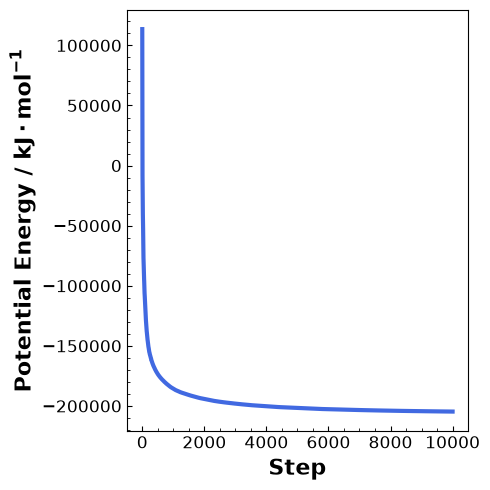

In [20]:
import numpy as np
import matplotlib.pyplot as plt

minim_log = np.loadtxt(
    "exercise-1/2RVD_energy.xvg", 
    comments = ("#", "@") # Ignore all lines that start with any of these characters
)

fig, ax = plt.subplots(
    figsize = (5,5),
    layout = "tight"
)

ax.plot(
    minim_log[:,0], minim_log[:,1], # First column will be simulation step, subsequent columns
    lw = 3, color = "royalblue"
)

ax.set_xlabel("Step", fontsize = 16, fontweight = "bold")
ax.set_ylabel(r"Potential Energy / $\mathbf{kJ \cdot mol^{-1}}$", fontsize = 16, fontweight = "bold")

ax.minorticks_on()

ax.tick_params(labelsize = 12, which = "both", direction = "in")

What can you tell me about this graph? Interpret it.

### 1.5 - Equilibration

We have generated a conformation that, given the force field parameters, has a negative potential energy and is thus thermodynamically stable. That conformation, however, is completely static, and to obtain a conformational *ensemble* we need to run dynamics. In any case, we usually cannot jump immediately to *production* dynamics. This is, biomolecular systems usually have a lot of degrees of freedom and slow modes that take time to reach an equilibrium state. Therefore, most of the times after running an energy minimisation, we will run some equilibration steps.

Most typically, we will start with an NVT equilibration, that is, in a thermodynamic enseble with constant number of particles (N), volume (V) and temperature (T). We will start by first taking a look at the [`.mdp` file](mdp/eq_nvt.mdp).

```text
; Run control
integrator              = md        ; Leap-frog integrator
dt                      = 0.002     ; ps = 2 fs
nsteps                  = 500000    ; 500000 * 0.002 ps = 1000 ps = 1 ns

; Output control
nstlog                  = 1000 ; Every 2 ps
nstenergy               = 1000 ; Every 2 ps
nstxout-compressed      = 5000 ; Every 10 ps

[...]

; Temperature coupling
tcoupl                  = V-rescale
tc-grps                 = Protein Water_and_Ions
tau-t                   = 1.0 1.0
ref-t                   = 340 340

; Initial velocities
gen-vel                 = yes
gen-temp                = 300
gen-seed                = -1


; Pressure coupling
pcoupl                  = no
```

Here we have set `integrator = md` and therefore we are requesting actual dynamics using the [Leapfrog integrator](https://en.wikipedia.org/wiki/Leapfrog_integration). We request a timestep of 2 femtoseconds, relatively conservative since this is the first equilibration step; and we run it for 500000 steps for a total of 1 ns simulated time. The next section refers to how often we will write to file the results of the simulation. The first two items tell about the `.log` and the `.edr` file, respectively; and the last item relates to he frequency with which we will write an `.xtc` trajectory file. The `compressed` part is because `.xtc` files do NOT store velocities of forces for each particle, unlike `.trr` files.

Next we can generate the appropriate binary

```bash
gmx grompp -f mdp/eq_nvt.mdp -c exercise-1/2RVD_minim.gro -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_nvt.tpr
```

You should see the following line

```text
Velocities were taken from a Maxwell distribution at 340 K
```

Why do you think is that? Then, run the simulation

```bash
gmx mdrun -v -deffnm exercise-1/2RVD_nvt
```

We can visualise the simulation result as follows:

In [30]:
import MDAnalysis.transformations as trans

u_nvt = mda.Universe(
    "exercise-1/2RVD_minim.gro",
    "exercise-1/2RVD_nvt.xtc",
    to_guess = ["bonds", "masses"]
)

protein = u_nvt.select_atoms("protein")
solvent = u_nvt.select_atoms("not protein")

u_nvt.trajectory.add_transformations(
    trans.unwrap(protein),
    trans.center_in_box(protein, center="mass"),
    trans.wrap(solvent, compound="residues"),
)

view = nv.show_mdanalysis(u_nvt)
view.clear_representations()

view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="protein")
view.add_unitcell()

view

NGLWidget(max_frame=100)

But, of course, we will need to monitor some more things to see how our equilibration is going. We can postprocess again the `.edr` file and obtain the relevant quantities from it.

```bash
gmx energy -f exercise-1/2RVD_nvt.edr -o exercise-1/2RVD_nvt.xvg
```

When prompted, select Total Energy, Temperature and Pressure. Then, we can plot the results:

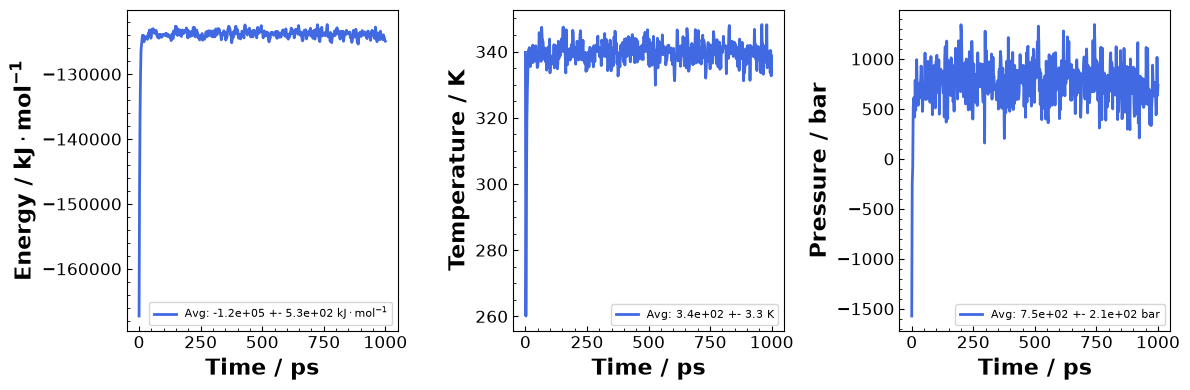

In [49]:
nvt_edr = np.loadtxt(
    "exercise-1/2RVD_nvt.xvg",
    comments = ("#", "@")
)

time        = nvt_edr[:,0]
energy      = nvt_edr[:,1]
temperature = nvt_edr[:,2]
pressure    = nvt_edr[:,3]

fig, ax = plt.subplots(
    1, 3,
    figsize = (12, 4),
    layout = "tight"
)

ax[0].plot(
    time, energy,
    color = "royalblue", lw = 2,
    label = rf"Avg: {np.mean(energy[-250:]):.2g} +- {np.std(energy[-250:], ddof = 1):.2g} $\mathrm{{kJ \cdot mol^{{-1}}}}$"
)
ax[1].plot(
    time, temperature,
    color = "royalblue", lw = 2,
    label = f"Avg: {np.mean(temperature[-250:]):.2g} +- {np.std(temperature[-250:], ddof = 1):.2g} K"
)
ax[2].plot(
    time, pressure,
    color = "royalblue", lw = 2,
    label = f"Avg: {np.mean(pressure[-250:]):.2g} +- {np.std(pressure[-250:], ddof = 1):.2g} bar"
)

ax[0].set_ylabel(
    r"Energy / $\mathbf{kJ} \cdot \mathbf{mol^{-1}}$",
    fontsize = 16, fontweight = "bold"
)
ax[1].set_ylabel(
    r"Temperature / K",
    fontsize = 16, fontweight = "bold"
)
ax[2].set_ylabel(
    r"Pressure / bar",
    fontsize = 16, fontweight = "bold"
)

for ax_i in ax:
    ax_i.minorticks_on()
    ax_i.tick_params(
        which = "both",
        direction = "in",
        labelsize = 12
    )

    ax_i.set_xlabel(
        "Time / ps",
        fontsize = 16, fontweight = "bold"
    )

    ax_i.legend(fontsize = 8)

Discuss these results for a bit. Why does the total energy of the system increase? Is the thermostat working? Why is the pressure so high?

Indeed, we should do something about that pressure. That is why the next step is going to be an NPT simulation, where we will use a barostat to keep a constant pressure at a desired value. Let's take a look at the [relevant `.mdp` file](mdp/eq_npt.mdp)

```text
; Run control
integrator              = md        ; Leap-frog integrator
dt                      = 0.002     ; ps = 2 fs
nsteps                  = 500000    ; 500000 * 0.002 ps = 1000 ps = 1 ns

; Output control
nstlog                  = 1000
nstenergy               = 1000
nstxout-compressed      = 5000

[...]

; Temperature coupling
tcoupl                  = V-rescale
tc-grps                 = Protein Water_and_Ions
tau-t                   = 1.0 1.0
ref-t                   = 340 340

; Initial velocities
gen-vel                 = no

; Pressure coupling
pcoupl                  = C-rescale
pcoupltype              = isotropic
ref-p                   = 1.0
tau-p                   = 5.0
compressibility         = 4.5e-5
```

There are really only two differences with the previous instructions file. First, we have set up `gen-vel = no`; this is necessary since, as we have just seen, we have equilibrated the temperature of our system so generating the velocities again would undo that work. Then, we have set up `pcoupl = C-rescale`, this selects the [Stochastic Cell Rescaling barostat](https://doi.org/10.1063/5.0020514), a state-of-the-art pressure coupling scheme.

At this point, we should be quite familiar with what we need to do to prepare the binaries and run a simulation! Run, in a terminal:

```bash
gmx grompp -f mdp/eq_npt.mdp -c exercise-1/2RVD_nvt.gro -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_npt.tpr

gmx mdrun -v -deffnm exercise-1/2RVD_npt
```

We can again extract the relevant parameters to an `.xvg` file

```bash
gmx energy -f exercise-1/2RVD_npt.edr -o exercise-1/2RVD_npt.xvg
```

and plot it:

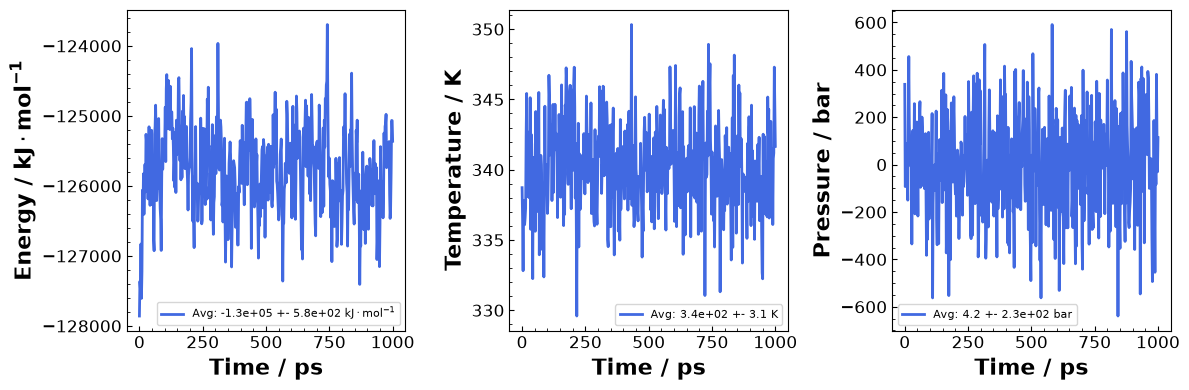

In [50]:
npt_edr = np.loadtxt(
    "exercise-1/2RVD_npt.xvg",
    comments = ("#", "@")
)

time        = npt_edr[:,0]
energy      = npt_edr[:,1]
temperature = npt_edr[:,2]
pressure    = npt_edr[:,3]

fig, ax = plt.subplots(
    1, 3,
    figsize = (12, 4),
    layout = "tight"
)

ax[0].plot(
    time, energy,
    color = "royalblue", lw = 2,
    label = rf"Avg: {np.mean(energy[-250:]):.2g} +- {np.std(energy[-250:], ddof = 1):.2g} $\mathrm{{kJ \cdot mol^{{-1}}}}$"
)
ax[1].plot(
    time, temperature,
    color = "royalblue", lw = 2,
    label = f"Avg: {np.mean(temperature[-250:]):.2g} +- {np.std(temperature[-250:], ddof = 1):.2g} K"
)
ax[2].plot(
    time, pressure,
    color = "royalblue", lw = 2,
    label = f"Avg: {np.mean(pressure[-250:]):.2g} +- {np.std(pressure[-250:], ddof = 1):.2g} bar"
)

ax[0].set_ylabel(
    r"Energy / $\mathbf{kJ} \cdot \mathbf{mol^{-1}}$",
    fontsize = 16, fontweight = "bold"
)
ax[1].set_ylabel(
    r"Temperature / K",
    fontsize = 16, fontweight = "bold"
)
ax[2].set_ylabel(
    r"Pressure / bar",
    fontsize = 16, fontweight = "bold"
)

for ax_i in ax:
    ax_i.minorticks_on()
    ax_i.tick_params(
        which = "both",
        direction = "in",
        labelsize = 12
    )

    ax_i.set_xlabel(
        "Time / ps",
        fontsize = 16, fontweight = "bold"
    )

    ax_i.legend(fontsize = 8)